# Temperature Series Exploratory Data Analysis

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", palette="rainbow", context="notebook")

In [103]:
### load preprocessed data
data = pd.read_csv('apsrht_datetime.csv', index_col='date_time', parse_dates=True)

## reapply 15-min frequency 
data = data.asfreq('15min')
data.head()

,measurement_number,temp_C,relative_hum_NaCl,relative_hum_Ice
date_time,,,,
2018-12-19 00:00:00,11549,-20.167,53.306,64.41
2018-12-19 00:15:00,11550,-20.073,53.239,64.29
2018-12-19 00:30:00,11551,-19.839,53.167,64.06
2018-12-19 00:45:00,11552,-19.700,53.189,63.99
2018-12-19 01:00:00,11553,-19.469,53.389,64.04


In [104]:
temp_series = data['temp_C']
temp_series.head()

date_time
2018-12-19 00:00:00   -20.167
2018-12-19 00:15:00   -20.073
2018-12-19 00:30:00   -19.839
2018-12-19 00:45:00   -19.700
2018-12-19 01:00:00   -19.469
Freq: 15min, Name: temp_C, dtype: float64

## Time Plot

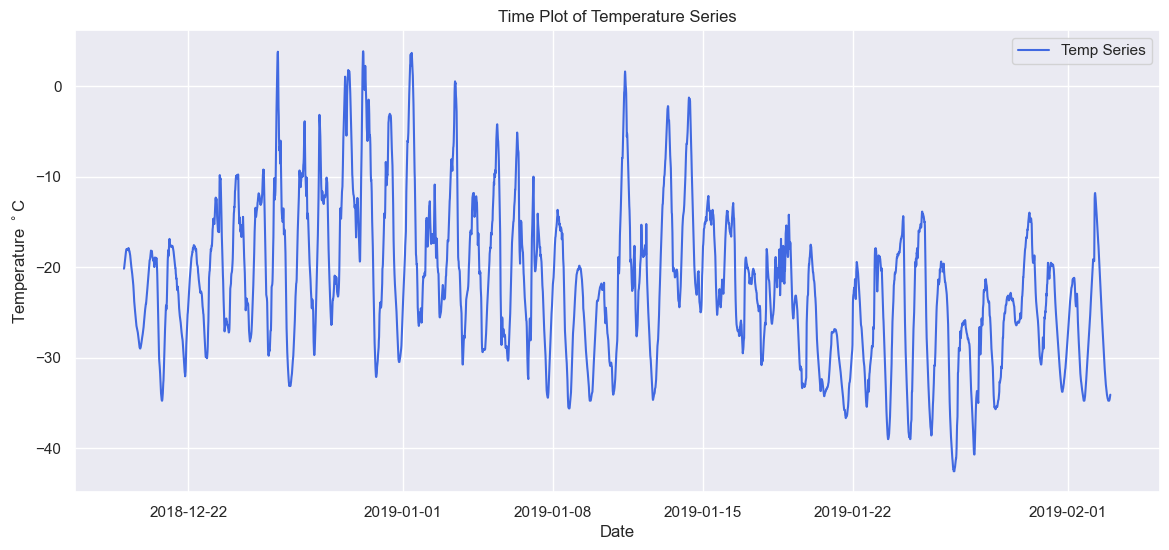

In [105]:
plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Temp Series', color='royalblue')
plt.title('Time Plot of Temperature Series')
plt.xlabel('Date')
plt.ylabel('Temperature $^\circ$C')
plt.legend()
plt.show()

## Trend Analysis

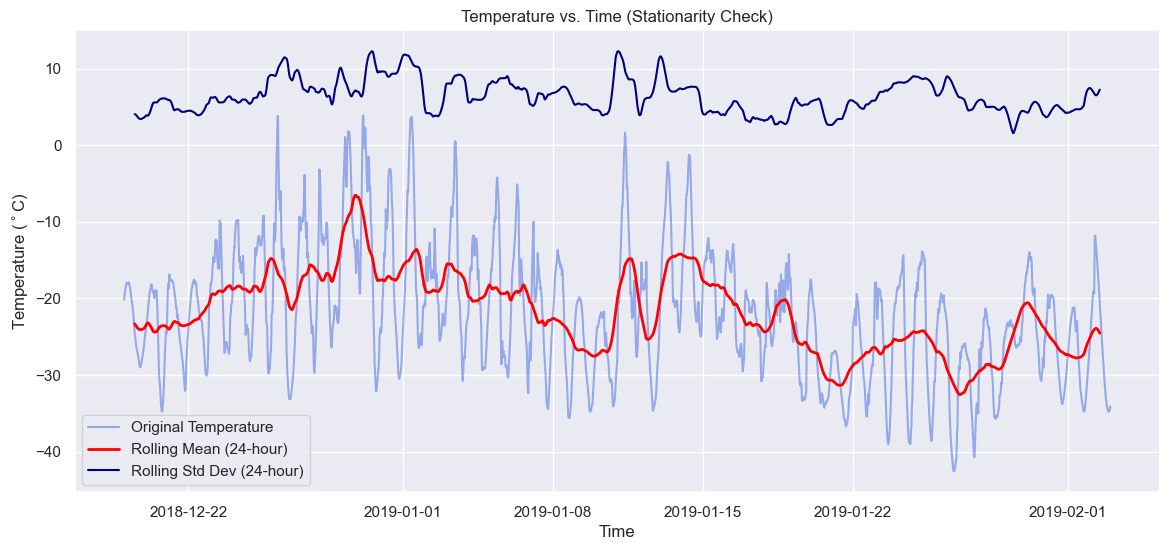

In [106]:
rolling_mean = temp_series.rolling(window=96, center=True).mean() # 96 periods of 15-min = 24 hours
rolling_std = temp_series.rolling(window=96, center=True).std()

plt.figure(figsize=(14, 6))
plt.plot(temp_series, label='Original Temperature', color='royalblue', alpha=0.5)
plt.plot(rolling_mean, label='Rolling Mean (24-hour)', color='red', linewidth=2)
plt.plot(rolling_std, label='Rolling Std Dev (24-hour)', color='navy')
plt.title(r'Temperature vs. Time (Stationarity Check)')
plt.xlabel('Time')
plt.ylabel(r'Temperature ($^\circ$C)')
plt.legend(loc='best')
plt.show()

## Seasonal Decomposition

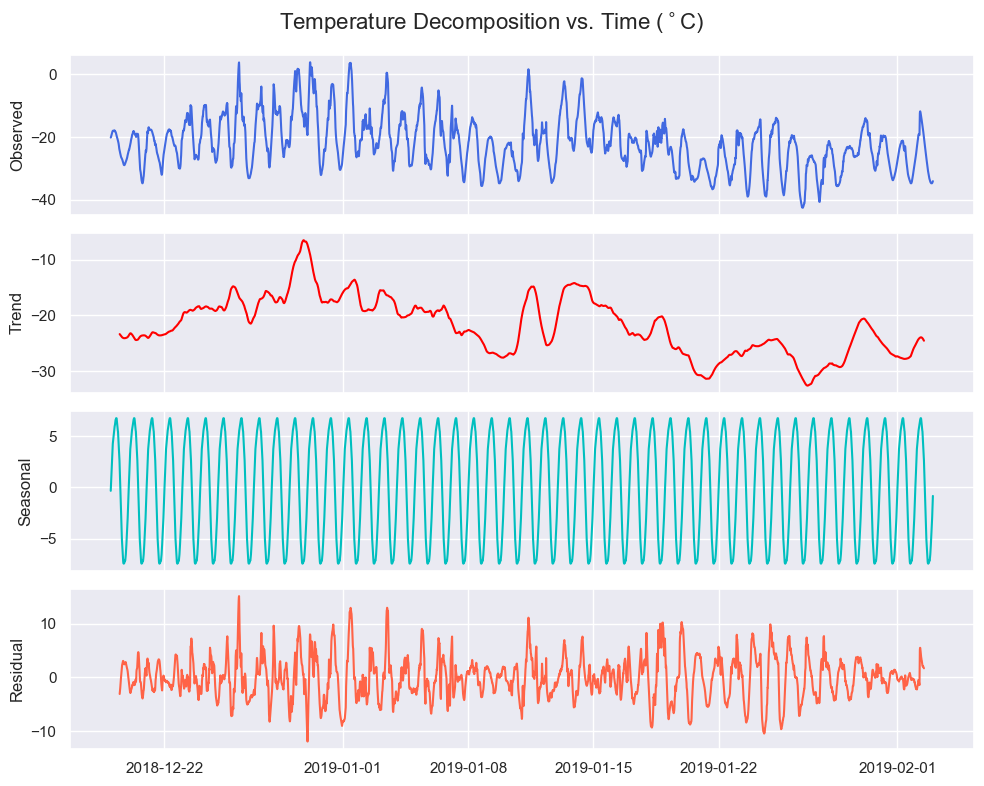

In [107]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(temp_series, model='additive', period=96)

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
ax[0].plot(decomposition.observed, color='royalblue')
ax[0].set_ylabel('Observed')
ax[1].plot(decomposition.trend, color='red')
ax[1].set_ylabel('Trend')
ax[2].plot(decomposition.seasonal, color='c')
ax[2].set_ylabel('Seasonal')
ax[3].plot(decomposition.resid, color='tomato')
ax[3].set_ylabel('Residual')
fig.suptitle(r'Temperature Decomposition vs. Time ($^\circ$C)', fontsize=16)
plt.tight_layout()
plt.show()

## Boxplots

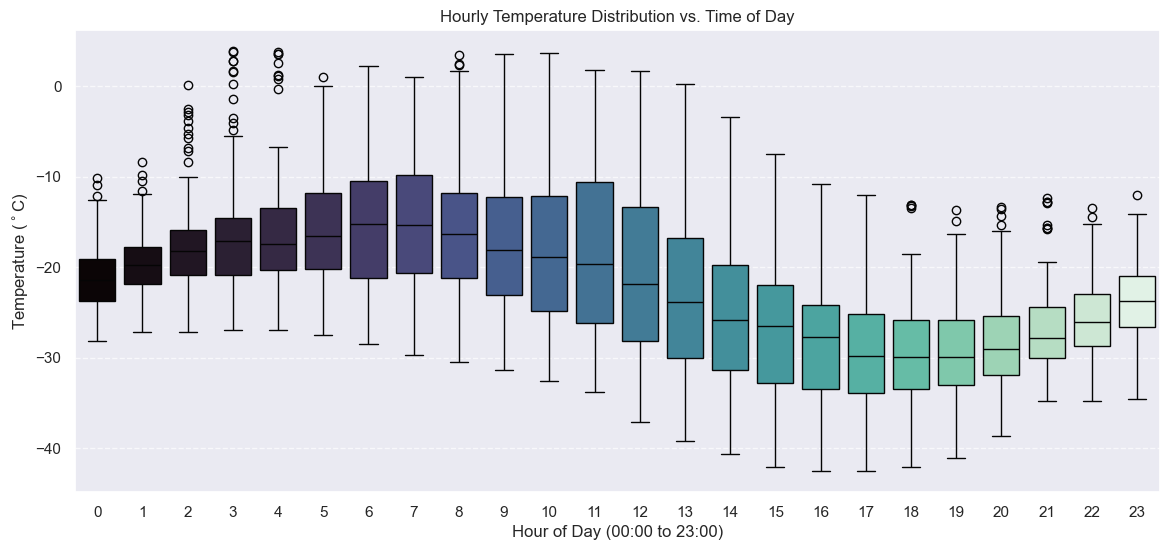

In [108]:
### daily cycle boxplot
df_plot = data.copy()

### extract the hour (0 to 23) from the datetime index
df_plot['Hour'] = df_plot.index.hour

### plot the hourly distribution
plt.figure(figsize=(14, 6))
sns.boxplot(x='Hour', y='temp_C', data=df_plot, palette='mako', hue='Hour', legend=False)
plt.title(r'Hourly Temperature Distribution vs. Time of Day')
plt.xlabel('Hour of Day (00:00 to 23:00)')
plt.ylabel(r'Temperature ($^\circ$C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

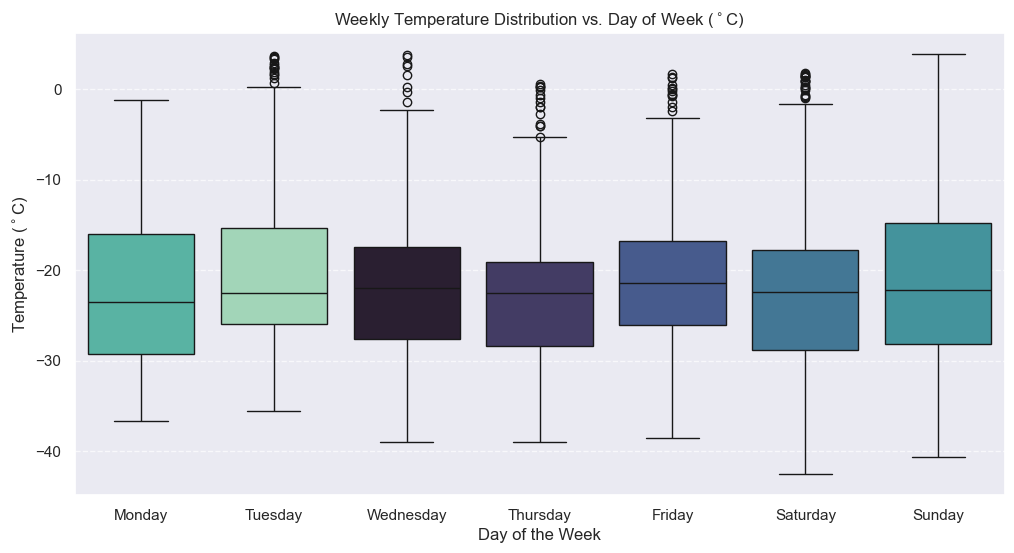

In [109]:
### weekly cycle boxplot

### extract the day name from the datetime index
df_plot['Day'] = data.index.day_name()

### chronologically order days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

### plot weekly distribution
plt.figure(figsize=(12, 6))
sns.boxplot(x='Day', y='temp_C', data=df_plot, order=days_order, palette='mako', hue='Day', legend=False)

plt.title(r'Weekly Temperature Distribution vs. Day of Week ($^\circ$C)')
plt.xlabel('Day of the Week')
plt.ylabel(r'Temperature ($^\circ$C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Autocorrelation Plots

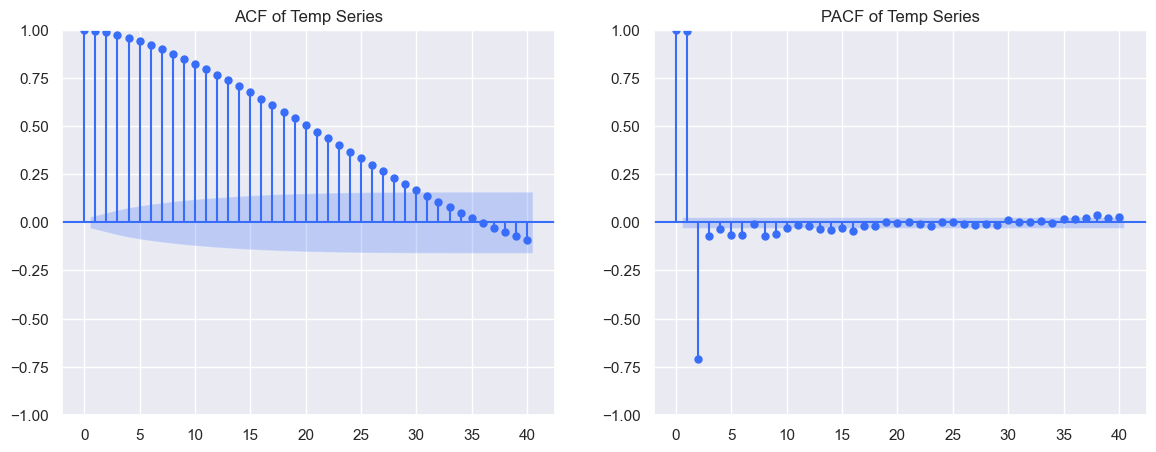

In [110]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(temp_series, lags=40, ax=ax[0])
ax[0].set_title('ACF of Temp Series')
plot_pacf(temp_series, lags=40, method='ywm', ax=ax[1])
ax[1].set_title('PACF of Temp Series')
plt.show()

## Stationarity and Augmented Dickey-Fuller Test

In [111]:
from statsmodels.tsa.stattools import adfuller

adf_stat, adf_pvalue, _, _, _, _ = adfuller(temp_series.dropna())
print(f'ADF Test Statistic: {adf_stat:.3f}')
print(f'ADF p-value: {adf_pvalue:.3f}')

ADF Test Statistic: -10.948
ADF p-value: 0.000


## Differencing

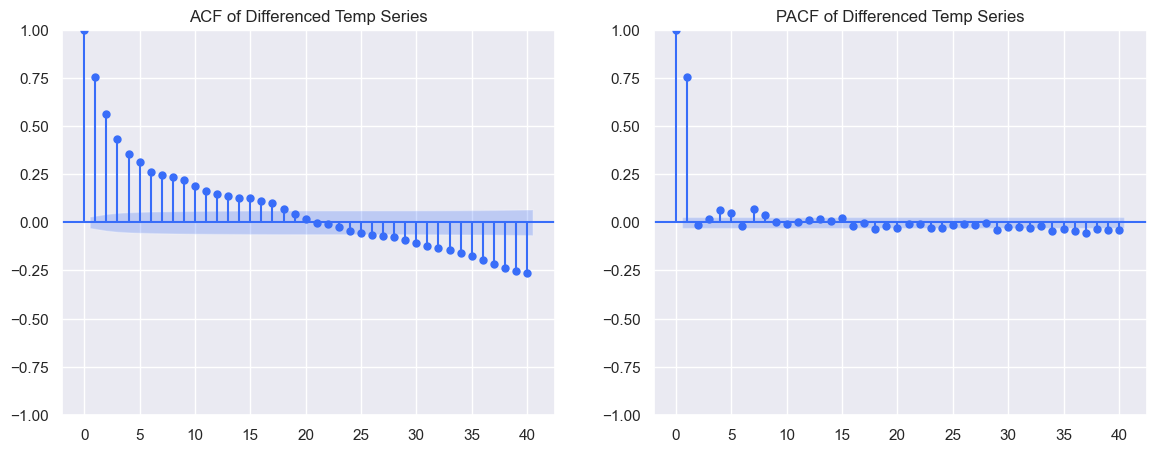

In [112]:
temp_series_diff = temp_series.diff().dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(temp_series_diff, lags=40, ax=ax[0])
ax[0].set_title('ACF of Differenced Temp Series')
plot_pacf(temp_series_diff, lags=40, ax=ax[1], method='ywm')
ax[1].set_title('PACF of Differenced Temp Series')
plt.show()

In [113]:
adf_stat, adf_pvalue, _, _, _, _ = adfuller(temp_series_diff.dropna())
print(f'ADF Test Statistic: {adf_stat:.3f}')
print(f'ADF p-value: {adf_pvalue:.3f}')

ADF Test Statistic: -14.722
ADF p-value: 0.000


## Detect Outliers

In [114]:
# detect outliers using 3 sigma rule
mean_ts = temp_series.mean()
std_ts = temp_series.std()
upper_bound = mean_ts + 3*std_ts
lower_bound = mean_ts - 3*std_ts
outliers = temp_series[(temp_series > upper_bound) | (temp_series < lower_bound)]
print('Detected outlier(s):')
print(outliers)

Detected outlier(s):
date_time
2018-12-26 04:00:00    3.538
2018-12-26 04:15:00    3.827
2018-12-30 03:30:00    3.827
2018-12-30 03:45:00    3.880
2018-12-30 04:00:00    3.617
2019-01-01 08:45:00    3.433
2019-01-01 09:00:00    3.564
2019-01-01 10:00:00    3.696
2019-01-01 10:15:00    3.301
Name: temp_C, dtype: float64
